In [1]:
import os
import time
import numpy as np
import pandas as pd

from skimage import io

from CellMet.segmentation import Segmentation
from CellMet.analysis import cell_analysis, edge_analysis, face_analysis
import ZebrafishMuscle.plot as ZMplot

import plotly.graph_objects as go
import matplotlib.pyplot as plt

%load_ext snakeviz

In [2]:
%pdb

Automatic pdb calling has been turned ON


In [3]:
# path = "/mnt/sda1/images/"
# seg_filename = "E4_36hpf_CAAXxZO1tdTom(d)-2_cp_masks.tif"
path = "/mnt/sda1/CellMetPaperDatas/Heart_data_protrusion/"
seg_filename = "Process_20220923_Line_44_09_5ADVMLE.vsi - 009 488-t11_crop_mask.tif"
pixel_size = dict(x_size = 0.1071804,
                  y_size = 0.1071804,
                  z_size = 0.1071804,)

# pixel_size = dict(x_size = 0.183,
#                   y_size = 0.183,
#                   z_size = 0.5,)

In [4]:

image = io.imread(os.path.join(path, seg_filename))


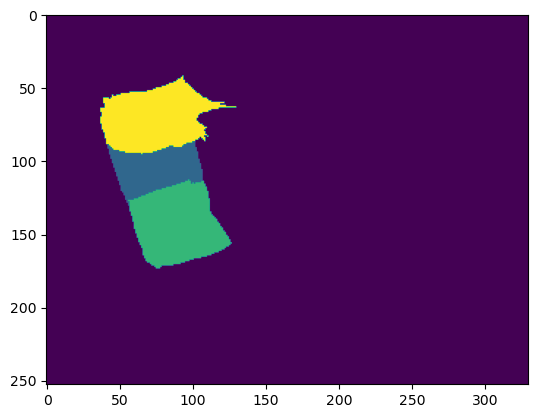

In [5]:
plt.imshow(image.max(axis=0))

In [6]:
seg = Segmentation(image, pixel_size, path)

In [7]:
%%snakeviz
start_time = time.time()
seg.perform_prerequisite(save_mesh=True)
# print("--- %s seconds ---" % (time.time() - start_time))

This folder obj_mesh is not empty, 
If you want to save file here, turn overwrite to True


Save mesh:   0%|          | 0/3 [00:00<?, ?it/s]

 
*** Profile stats marshalled to file '/tmp/tmp0nrq3dxf'.
Embedding SnakeViz in this document...
<function display at 0x7b77467cfba0>


In [8]:
%%snakeviz
start_time = time.time()
seg.cell_segmentation()
# print("--- %s seconds ---" % (time.time() - start_time))
# 168 sec

Cell:   0%|          | 0/3 [00:00<?, ?it/s]

 
*** Profile stats marshalled to file '/tmp/tmpexbax1o1'.
Embedding SnakeViz in this document...
<function display at 0x7b77467cfba0>


In [25]:
%%snakeviz
start_time = time.time()
seg.edge_segmentation()
# print("--- %s seconds ---" % (time.time() - start_time))
#2.09e+3

Cell:   0%|          | 0/3 [00:00<?, ?it/s]

Edge segmentation:   0%|          | 0/1 [00:00<?, ?it/s]

Edge segmentation: 0it [00:00, ?it/s]

Edge segmentation: 0it [00:00, ?it/s]

 
*** Profile stats marshalled to file '/tmp/tmpbx2xuput'.
Embedding SnakeViz in this document...
<function display at 0x7b77467cfba0>


In [26]:
%%snakeviz
start_time = time.time()
seg.face_segmentation()
# print("--- %s seconds ---" % (time.time() - start_time))

Cell:   0%|          | 0/3 [00:00<?, ?it/s]

 
*** Profile stats marshalled to file '/tmp/tmpp_ttg9yq'.
Embedding SnakeViz in this document...
<function display at 0x7b77467cfba0>


In [50]:
import sparse
import CellMet.image as csimage
import CellMet.utils as csutils
i=1
c_id = seg.unique_id_cells[i]
print(c_id)
# step 1
sp_mat = sparse.load_npz(os.path.join(seg.storage_path, "npz/" + str(c_id) + ".npz"))
img_cell1_dil = sp_mat.todense()

img_cell1_dil[img_cell1_dil == 2] = 1
neighbours_id, _ = csimage.find_neighbours_cell_id(img_cell1_dil, seg.label_image, by_plane=False)

opp_cell = np.delete(neighbours_id, np.where(neighbours_id == c_id))



2
[1 2] [1]


In [49]:
from CellMet.segmentation import find_all_neighbours
i=1
c_id = seg.unique_id_cells[i]
# open file
sp_mat = sparse.load_npz(os.path.join(seg.storage_path, "npz/" + str(c_id) + ".npz"))
img_cell_dil = sp_mat.todense()
img_cell_dil[img_cell_dil == 2] = 1

sub_edges = edge_df[edge_df['id_im_1'] == c_id]

ordered_neighbours, opp_cell = find_all_neighbours(sub_edges)
ordered_neighbours, opp_cell

([], {})

In [11]:
%%snakeviz
edge_analysis(seg)

 
*** Profile stats marshalled to file '/tmp/tmpbvi4zm0k'.
Embedding SnakeViz in this document...
<function display at 0x7b77467cfba0>


In [12]:
%%snakeviz
cell_analysis(seg, parallelized=True, degree_convert=True)

Cell analysis:   0%|          | 0/3 [00:00<?, ?it/s]

 
*** Profile stats marshalled to file '/tmp/tmp6tjawj8u'.
Embedding SnakeViz in this document...
<function display at 0x7b77467cfba0>


In [13]:
%%snakeviz
face_analysis(seg)

 
*** Profile stats marshalled to file '/tmp/tmpq0oowkk5'.
Embedding SnakeViz in this document...
<function display at 0x7b77467cfba0>


In [14]:
cell_df = pd.read_csv(os.path.join(path,"cell_df.csv"), index_col=0)
face_df = pd.read_csv(os.path.join(path,"face_df.csv"), index_col=0)
edge_df = pd.read_csv(os.path.join(path,"edge_df.csv"), index_col=0)

face_pixel_df = pd.read_csv(os.path.join(path,"face_pixel_df.csv"), index_col=0)
edge_pixel_df = pd.read_csv(os.path.join(path,"edge_pixel_df.csv"), index_col=0)

In [20]:
edge_df

,id_im_1,id_im_2,id_im_3,x_center,y_center,z_center,real_dist,short_dist,tortuosity


In [24]:
fig = go.Figure()
color_l = ["red", "grey", "blue", "green"]
for c_id in [1,2,3]:
# c_id = 79
    fig = ZMplot.draw_cell(image, c_id, fig=fig, **{"opacity":0.1, "color":color_l[c_id]})
    fig = ZMplot.draw_face(face_pixel_df, c_id, dict(x_size=1, y_size=1, z_size=1), fig=fig,)
    fig = ZMplot.draw_edges(edge_df, edge_pixel_df, c_id, dict(x_size=1, y_size=1, z_size=1), fig=fig)

fig.update_layout(title='Cell center, edge position',
              autosize=False,
              width=900,
              height=900,
              margin=dict(l=65, r=50, b=65, t=90),
              showlegend=False,
              scene = dict(
                aspectratio=dict(x=0.5, 
                                 y=pixel_size["x_size"], 
                                 z=pixel_size["x_size"]),
                ),
              )

fig.update_scenes(xaxis_visible=False, yaxis_visible=False,zaxis_visible=False )

In [76]:
cell_df

,id_im,x_center,y_center,z_center,nb_neighbor,volume,area,real_dist,short_dist,curv_ind,orient_zy,orient_xy,orient_xz,x_start,y_start,z_start,x_end,y_end,z_end
0,33,62.827200,88.899310,112.468425,3,154.234950,1117.784392,9.724395,4.230692,0.564940,90.634821,-94.068935,-8.853281,82.574661,87.432127,92.0,76.5,87.0,131.0
1,35,140.166484,84.841223,110.504822,4,145.403196,1142.543064,9.645814,5.391624,0.441040,86.095786,-82.149214,-26.333221,139.272859,83.928882,85.0,117.0,87.0,130.0
2,46,206.604167,85.364340,105.522424,4,139.804704,1078.663546,11.533924,5.128323,0.555371,91.659783,92.336506,35.381410,199.303183,86.130095,85.0,227.0,85.0,124.0
3,48,267.065038,88.490631,104.376916,3,124.878265,997.635163,7.213553,4.475222,0.379609,74.155450,18.558965,5.443102,248.188525,78.647541,84.0,252.0,90.0,124.0
4,53,133.272887,44.852517,94.575360,5,158.726549,1267.944132,14.437191,5.662907,0.607756,76.357141,-58.154929,-21.344385,118.757267,48.349564,74.0,100.0,60.0,122.0
5,69,62.500964,44.197029,97.142917,3,141.746385,1106.316089,12.553788,5.389602,0.570679,63.598965,5.468857,2.721114,79.361233,34.660793,75.0,81.5,57.0,120.0
6,79,211.917411,41.534546,88.838954,4,125.224246,1070.303474,19.636245,7.679388,0.608918,63.539550,65.368245,47.348317,194.065854,34.104878,65.0,244.0,57.0,111.0
7,85,280.686436,40.566500,88.768980,2,111.956300,894.206077,8.715587,5.167886,0.407052,77.930611,-75.173423,-38.930204,304.387454,35.088561,70.0,274.5,43.0,107.0


In [83]:
import networkx as nx
G = nx.Graph()
for c, row in cell_df.iterrows():
    G.add_node(row["id_im"], pos=row[["x_center", "y_center"]].to_numpy())
# G.add_nodes_from(cell_df["id_im"], pos=cell_df[["x_center", "y_center"]].to_numpy())
G.add_edges_from(face_df[["id_im_1", "id_im_2"]].to_numpy())

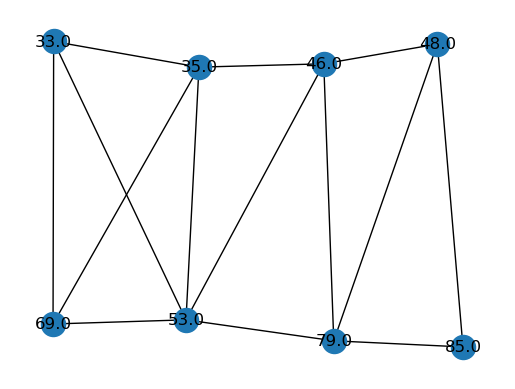

In [86]:
pos = nx.get_node_attributes(G,'pos')
fig, ax = plt.subplots()
nx.draw(G, with_labels=True,pos=pos, ax=ax)
fig.savefig(os.path.join(path, "network.eps"))

In [82]:
cell_df[["x_center", "y_center"]].to_numpy()[0]

array([62.82720006, 88.89931033])